# Jupiter grey-radiation model

A two-stream, semi-grey-gas radiation GCM for Jupiter, porting Isca's
`two_stream_gray_rad` "Schneider & Liu" giant-planet configuration (plus its
constant internal-heat-flux lower boundary) onto the `dinosaur` JAX
dynamical core. This runs on GPU if one is available (`jax.devices()`
below).

The physics (`dinosaur.grey_radiation.GiantPlanetGreyRadiation`) is checked
two ways here: first offline, as a single-column radiative-equilibrium
calculation (fast, and isolates the new radiation code from the dynamical
core); then coupled to the full primitive equations for a short 3D GPU
integration.

In [1]:
import sys
sys.path.insert(0, '.')  # so `jupiter_gcm_utils` (in this directory) imports

import dinosaur
from dinosaur import grey_radiation
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import jupiter_gcm_utils as jgu

units = dinosaur.scales.units

print('jax version:', jax.__version__)
print('devices:', jax.devices())

jax version: 0.11.1


devices: [CudaDevice(id=0)]


In [2]:
from dinosaur import dry_convection

physics_specs = dinosaur.primitive_equations.PrimitiveEquationsSpecs.from_si()

layers = 60
scale_heights = 11
p0_si = 25e5 * units.pascal
p0 = physics_specs.nondimensionalize(p0_si)
kappa = physics_specs.kappa
gravity = physics_specs.g
cp = physics_specs.Cp

sigma_coords = dinosaur.sigma_coordinates.SigmaCoordinates.equidistant_log(layers, scale_heights)
p_half = jnp.asarray(sigma_coords.boundaries[:, None, None] * p0)
p_full = jnp.asarray(sigma_coords.centers[:, None, None] * p0)
dp_half = p_half[1:] - p_half[:-1]

# Grey-radiation parameters (Isca giant-planet / Schneider & Liu defaults).
sw_tau_0, sw_tau_exponent = 3.0, 1.0
lw_tau_0, lw_tau_exponent = 80.0, 2.0
single_scattering_albedo, back_scatter = 0.8, 0.398
surface_albedo = 0.0
g_asym = 1 - 2 * back_scatter
s1 = np.sqrt(1 - g_asym * single_scattering_albedo)
s2 = np.sqrt(1 - single_scattering_albedo)
scattering_albedo = (s1 - s2) / (s1 + s2)
ga_asym = 2 * s2 * s1

solar_constant_nondim = physics_specs.nondimensionalize(50.7 * units.W / units.m**2)
flux_heat_gp_nondim = physics_specs.nondimensionalize(5.7 * units.W / units.m**2)
stefan_boltzmann_nondim = physics_specs.nondimensionalize(dinosaur.scales.STEFAN_BOLTZMANN)

lat_col = 0.0  # equator; try +/- 1.0 or so to see the effect of insolation
insolation = (solar_constant_nondim / np.pi) * np.cos(lat_col) * jnp.ones((1, 1))

# Dry convective adjustment parameters (Isca giant-planet defaults).
tau_conv = physics_specs.nondimensionalize(21600 * units.s)
gamma_conv = 1.0


def column_heating(temperature):
  tau_lw = grey_radiation.longwave_tau(p_half, lw_tau_0, lw_tau_exponent, p0)
  dtrans = grey_radiation.longwave_dtrans(tau_lw)
  sw_down = grey_radiation.shortwave_down_flux(
      p_half, insolation, sw_tau_0, sw_tau_exponent, p0,
      scattering_albedo, ga_asym,
  )
  blackbody = stefan_boltzmann_nondim * temperature**4
  lw_down, lw_up = grey_radiation.longwave_fluxes(
      blackbody, dtrans, sw_down[-1], surface_albedo
  )
  sw_up = surface_albedo * sw_down[-1]
  rad_flux = (lw_up - lw_down) + (sw_up - sw_down)
  rad_heating = grey_radiation.radiative_heating_rate(rad_flux, p_half, gravity, cp)
  rad_heating = rad_heating + grey_radiation.internal_heat_tendency(
      p_half, flux_heat_gp_nondim, gravity, cp
  )

  tp = dry_convection.parcel_temperature(temperature, p_full, gamma_conv, kappa)
  conv_heating = dry_convection.adjustment_tendency(temperature, tp, dp_half, tau_conv)

  return rad_heating + conv_heating, rad_heating, conv_heating

In [3]:
dt_si = 0.25 * units.day
dt = physics_specs.nondimensionalize(dt_si)
temperature0 = physics_specs.nondimensionalize(200.0 * units.degK) * jnp.ones((layers, 1, 1))


@jax.jit
def relax_to_equilibrium(temperature0, n_iter):
  def body(i, temperature):
    heating, _, _ = column_heating(temperature)
    return temperature + dt * heating
  return jax.lax.fori_loop(0, n_iter, body, temperature0)


n_iter = 20000
print(f'Running on device(s): {jax.devices()}')
temperature_eq = jax.block_until_ready(relax_to_equilibrium(temperature0, n_iter))

total_heating, rad_heating, conv_heating = column_heating(temperature_eq)
print('max |total heating| (nondim) at equilibrium:', float(jnp.max(jnp.abs(total_heating))))
print('  of which from convection:', float(jnp.max(jnp.abs(conv_heating))))

Running on device(s): [CudaDevice(id=0)]


max |total heating| (nondim) at equilibrium: 0.0001544286496937275
  of which from convection: 0.0


theta monotonically decreasing with depth (stable column): True


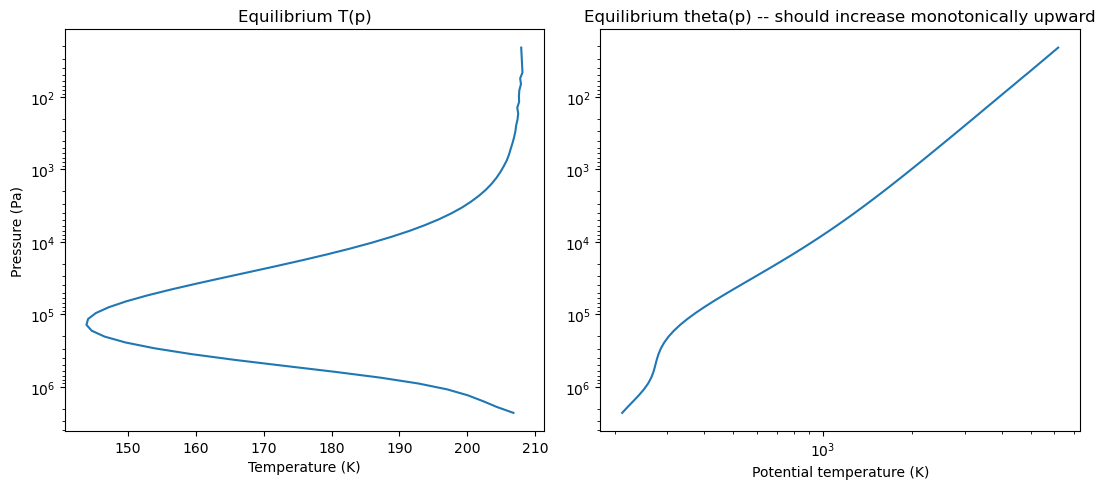

In [4]:
t_si = physics_specs.dimensionalize(temperature_eq, units.degK)
p_full_si = physics_specs.dimensionalize(p_full, units.pascal)
theta_nondim = temperature_eq * (p0 / p_full) ** kappa
theta_si = physics_specs.dimensionalize(theta_nondim, units.degK)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

axes[0].plot(t_si.magnitude[:, 0, 0], p_full_si.magnitude[:, 0, 0])
axes[0].set_yscale('log')
axes[0].invert_yaxis()
axes[0].set_xlabel('Temperature (K)')
axes[0].set_ylabel('Pressure (Pa)')
axes[0].set_title('Equilibrium T(p)')

axes[1].plot(theta_si.magnitude[:, 0, 0], p_full_si.magnitude[:, 0, 0])
axes[1].set_yscale('log')
axes[1].invert_yaxis()
axes[1].set_xscale('log')
axes[1].set_xlabel('Potential temperature (K)')
axes[1].set_title('Equilibrium theta(p) -- should increase monotonically upward')
plt.tight_layout()

is_stable = bool(np.all(np.diff(theta_si.magnitude[:, 0, 0]) <= 0))
print(f'theta monotonically decreasing with depth (stable column): {is_stable}')

In [5]:
coords = jgu.build_coords(layers=layers, scale_heights=scale_heights, horizontal_grid='T42')
state, ref_temps, orography = jgu.initial_state(coords, physics_specs, p0=p0_si)

radiation_forcing = dinosaur.grey_radiation.GiantPlanetGreyRadiation(
    coords=coords,
    physics_specs=physics_specs,
    reference_temperature=ref_temps,
    p0=p0_si,
)
convection_forcing = dinosaur.dry_convection.DryConvectiveAdjustment(
    coords=coords,
    physics_specs=physics_specs,
    reference_temperature=ref_temps,
)
primitive = dinosaur.primitive_equations.PrimitiveEquations(
    ref_temps, orography, coords, physics_specs
)

final_state, ds, elapsed = jgu.run_integration(
    [primitive, radiation_forcing, convection_forcing],
    coords,
    physics_specs,
    state,
    ref_temps,
    dt_si=10 * units.minute,
    save_every=6 * units.hour,
    total_time=2 * units.day,
)
ds

Running on device(s): [CudaDevice(id=0)]


Integration took 12.3s for 288 steps


/home/links/sit204/miniforge3/envs/dino/lib/python3.12/site-packages/jax/_src/numpy/array_constructors.py:314: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  out = np.asarray(object, dtype=dtype)


/home/links/sit204/miniforge3/envs/dino/lib/python3.12/site-packages/xarray/core/indexes.py:469: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  index = pd.Index(np.asarray(array), **kwargs)


<xarray.Dataset> Size: 95MB
Dimensions:                (time: 8, surface: 1, lon: 128, lat: 64, level: 60)
Coordinates:
  * lon                    (lon) float64 1kB 0.0 2.812 5.625 ... 354.4 357.2
  * lat                    (lat) float64 512B -87.86 -85.1 -82.31 ... 85.1 87.86
  * level                  (level) float64 480B 8.351e-06 1.841e-05 ... 0.915
  * surface                (surface) float64 8B 1.0
  * time                   (time) int64 64B 6 12 18 24 30 36 42 48
Data variables:
    log_surface_pressure   (time, surface, lon, lat) float32 262kB ...
    temperature_variation  (time, level, lon, lat) float32 16MB ...
    u                      (time, level, lon, lat) float32 16MB <Quantity([[[...
    divergence             (time, level, lon, lat) float32 16MB ...
    v                      (time, level, lon, lat) float32 16MB <Quantity([[[...
    vorticity              (time, level, lon, lat) float32 16MB ...
    surface_pressure       (time, lon, lat) float32 262kB <Quantity([[[2.5000...
    temperature            (time, level, lon, lat) float32 16MB <Quantity([[[...
    total_kinetic_energy   (time) float32 32B <Quantity([0.02376527 0.0271220...
Attributes:
    longitude_wavenumbers:     43
    total_wavenumbers:         44
    longitude_nodes:           128
    latitude_nodes:            64
    latitude_spacing:          gauss
    longitude_offset:          0.0
    radius:                    1.0
    spherical_harmonics_impl:  RealSphericalHarmonics
    spmd_mesh:                 
    boundaries:                [0.0, 1.670170079024566e-05, 2.012476680544426...
    horizontal_grid_type:      Grid
    vertical_grid_type:        SigmaCoordinates

12.3s for 288 steps on GPU (42.8 ms/step)


/home/links/sit204/miniforge3/envs/dino/lib/python3.12/site-packages/xarray/core/variable.py:339: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


Text(0.5, 1.0, 'Total kinetic energy vs time')

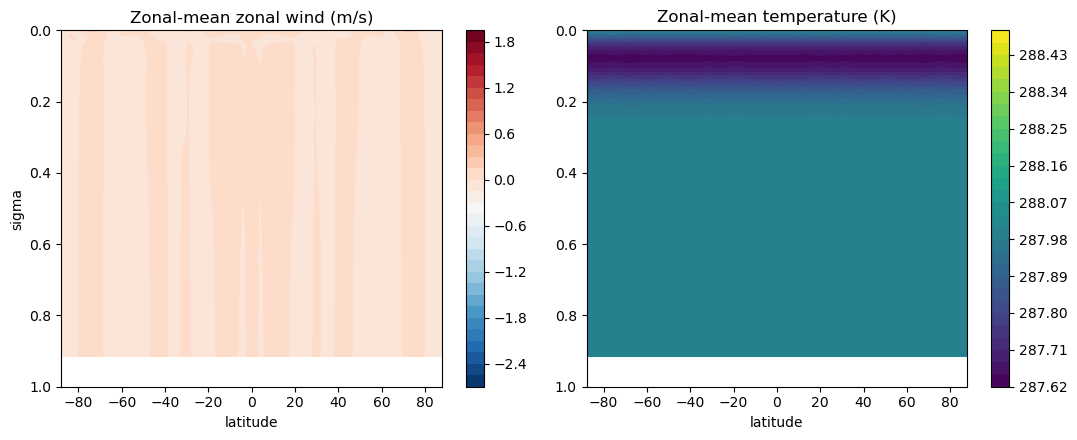

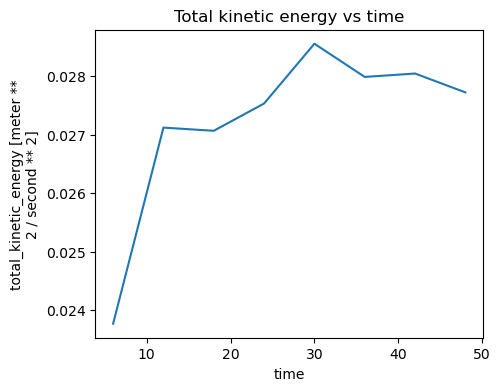

In [6]:
n_steps = int((2 * units.day) / (10 * units.minute))
print(f'{elapsed:.1f}s for {n_steps} steps on {jax.devices()[0].platform.upper()}'
      f' ({elapsed / n_steps * 1000:.1f} ms/step)')

final = ds.isel(time=-1)
u_zonal_mean = final.u.mean('lon')
t_zonal_mean = final.temperature.mean('lon')

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

cf = axes[0].contourf(final.lat, final.level, u_zonal_mean, levels=30, cmap='RdBu_r')
axes[0].set_ylim(1, 0)
axes[0].set_xlabel('latitude')
axes[0].set_ylabel('sigma')
axes[0].set_title('Zonal-mean zonal wind (m/s)')
plt.colorbar(cf, ax=axes[0])

cf = axes[1].contourf(final.lat, final.level, t_zonal_mean, levels=30)
axes[1].set_ylim(1, 0)
axes[1].set_xlabel('latitude')
axes[1].set_title('Zonal-mean temperature (K)')
plt.colorbar(cf, ax=axes[1])
plt.tight_layout()

plt.figure(figsize=(5, 4))
ds.total_kinetic_energy.plot()
plt.title('Total kinetic energy vs time')

## Post-integration diagnostics

Zonal-mean zonal wind and temperature at the final saved time, plus kinetic energy over the run and a wall-clock timing readout.

## Short 3D GPU integration

Couple `GiantPlanetGreyRadiation` and `DryConvectiveAdjustment` to the primitive equations and run forward, as a smoke test that everything composes and runs correctly on GPU. As with the Lian-Showman model this is deliberately short; the radiative and convective timescales here (days) are much faster than the Lian-Showman relaxation model's, so this model should show meaningful evolution over a shorter integration.

## Single-column radiative-convective equilibrium

Before coupling to the dynamical core, check the new physics in isolation: iterate a single atmospheric column (no horizontal dependence) forward under radiative + dry-convective heating alone until it settles, using the same pure functions the `GiantPlanetGreyRadiation`/`DryConvectiveAdjustment` classes are built from (`dinosaur.grey_radiation`, `dinosaur.dry_convection`).

Note: raw temperature `T(p)` is *not* the right quantity to judge convective stability from — a grey atmosphere with both shortwave and longwave absorption can have a perfectly stable, non-monotonic `T(p)` (e.g. a warm layer aloft). The right diagnostic is potential temperature `theta = T*(p0/p)**kappa`, which must increase monotonically with height (decrease with depth) for the column to be stable; that's what `dry_convection` actually checks internally, and what we plot below alongside `T(p)`.